# TEST: ripulire gli spettri LOCK-IN con un autoencoder

### Lettura dati

In [1]:
import numpy as np

# 1. Caricamento dati
f = np.arange(2500, 3250)
s_clean = np.load('../data/X_spectra_50k.npy')
B = np.load('../data/Y_B_field_50k.npy')

input_shape = s_clean.shape[1]

### Noising

In [2]:
from ml_odmr.noising import *

N_spettri = s_clean.shape[0]
N_punti = s_clean.shape[1]

# 2. Aggiunta rumore
s_noisy = np.zeros_like(s_clean)
ds_dx = np.zeros_like(s_clean)
ds_dx_noisy = np.zeros_like(s_clean)

for i in range(N_spettri):
    # sporco il segnale originale
    s_noisy[i] = add_poisson_noise(s_clean[i], scale=0.05)
    s_noisy[i] = add_poly_trend(f, s_noisy[i], scale=0.5)
    
    # calcolo la derivata numerica del segnale pulito
    ds_dx[i] = np.gradient(s_clean[i], f)
    # calcolo la derivata numerica del segnale sporco
    ds_dx_noisy[i] = np.gradient(s_noisy[i], f)
    # inverto la metà destra delle derivate
    for j in range(N_punti//2, N_punti):
        ds_dx[i][j] = -ds_dx[i][j]
        ds_dx_noisy[i][j] = -ds_dx_noisy[i][j]

### Scaling

Provo a scalare gli spettri. Ho già visto che Standard e MinMax non funzionano molto bene.

In [3]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
#ds_dx_scaled = scaler.fit_transform(ds_dx)
#ds_dx_noisy_scaled = scaler.transform(ds_dx_noisy)

### Modello

In [4]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Input
from tensorflow.keras.constraints import max_norm # per il max-norm constraint

In [5]:
from tensorflow.keras.layers import Conv1D, Conv1DTranspose, Reshape, Flatten

# Supponiamo input_shape = 500. Gli strati Conv1D vogliono un input 3D: (Batch, Lunghezza, Canali)
model = Sequential()
model.add(Input(shape=(input_shape, 1))) 

# ENCODER
model.add(Conv1D(32, kernel_size=7, strides=2, padding='same')) # Riduce la dimensionalità
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv1D(16, kernel_size=5, strides=2, padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))

# Bottleneck
model.add(Flatten())
model.add(Dense(8, name='bottleneck', kernel_constraint=max_norm(3)))
# Nota: per andare al decoder convoluzionale dobbiamo fare il reshape. 
# Se l'input era 500, dopo due strides=2 è diventato ~125.
model.add(Dense(125 * 16)) 
model.add(Reshape((125, 16)))

# DECODER
model.add(Conv1DTranspose(16, kernel_size=5, strides=2, padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv1DTranspose(1, kernel_size=7, strides=2, padding='same'))
# Output finale lineare per combaciare con input_shape
model.add(Flatten())
model.add(Dense(input_shape, activation='linear'))

In [8]:
# Compilazione
model.compile(optimizer='adam', loss='mean_absolute_error')#'mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 375, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 375, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 375, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 188, 16)        │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 188, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 188, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3008)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │        24,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2000)           │        18,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 125, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose                │ (None, 250, 16)        │         1,296 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 250, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 250, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_1              │ (None, 500, 1)         │           113 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 750)            │       375,750 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,319 (1.61 MB)

 Trainable params: 422,191 (1.61 MB)

 Non-trainable params: 128 (512.00 B)

In [9]:
# 4. Fit del modello (Denoising)
# x = input rumoroso, y = target pulito
history = model.fit(
    x=ds_dx_noisy, 
    y=ds_dx, 
    epochs=50,          # Sostituisci con il tuo no_epochs
    batch_size=32,      # Sostituisci con il tuo batch_size
    validation_split=0.2 # Usa il 20% dei dati per testare l'overfitting
)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 19ms/step - loss: 0.0129 - val_loss: 0.0090
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - loss: 0.0080 - val_loss: 0.0070
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - loss: 0.0062 - val_loss: 0.0055
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - loss: 0.0052 - val_loss: 0.0049
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - loss: 0.0046 - val_loss: 0.0041
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - loss: 0.0041 - val_loss: 0.0035
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - loss: 0.0034 - val_loss: 0.0030
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - loss: 0.0027 - val_loss: 0.0022
Epoch 9/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step - loss: 0.0022 - val_loss: 0.0018
Epoch 10/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 11/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 12

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


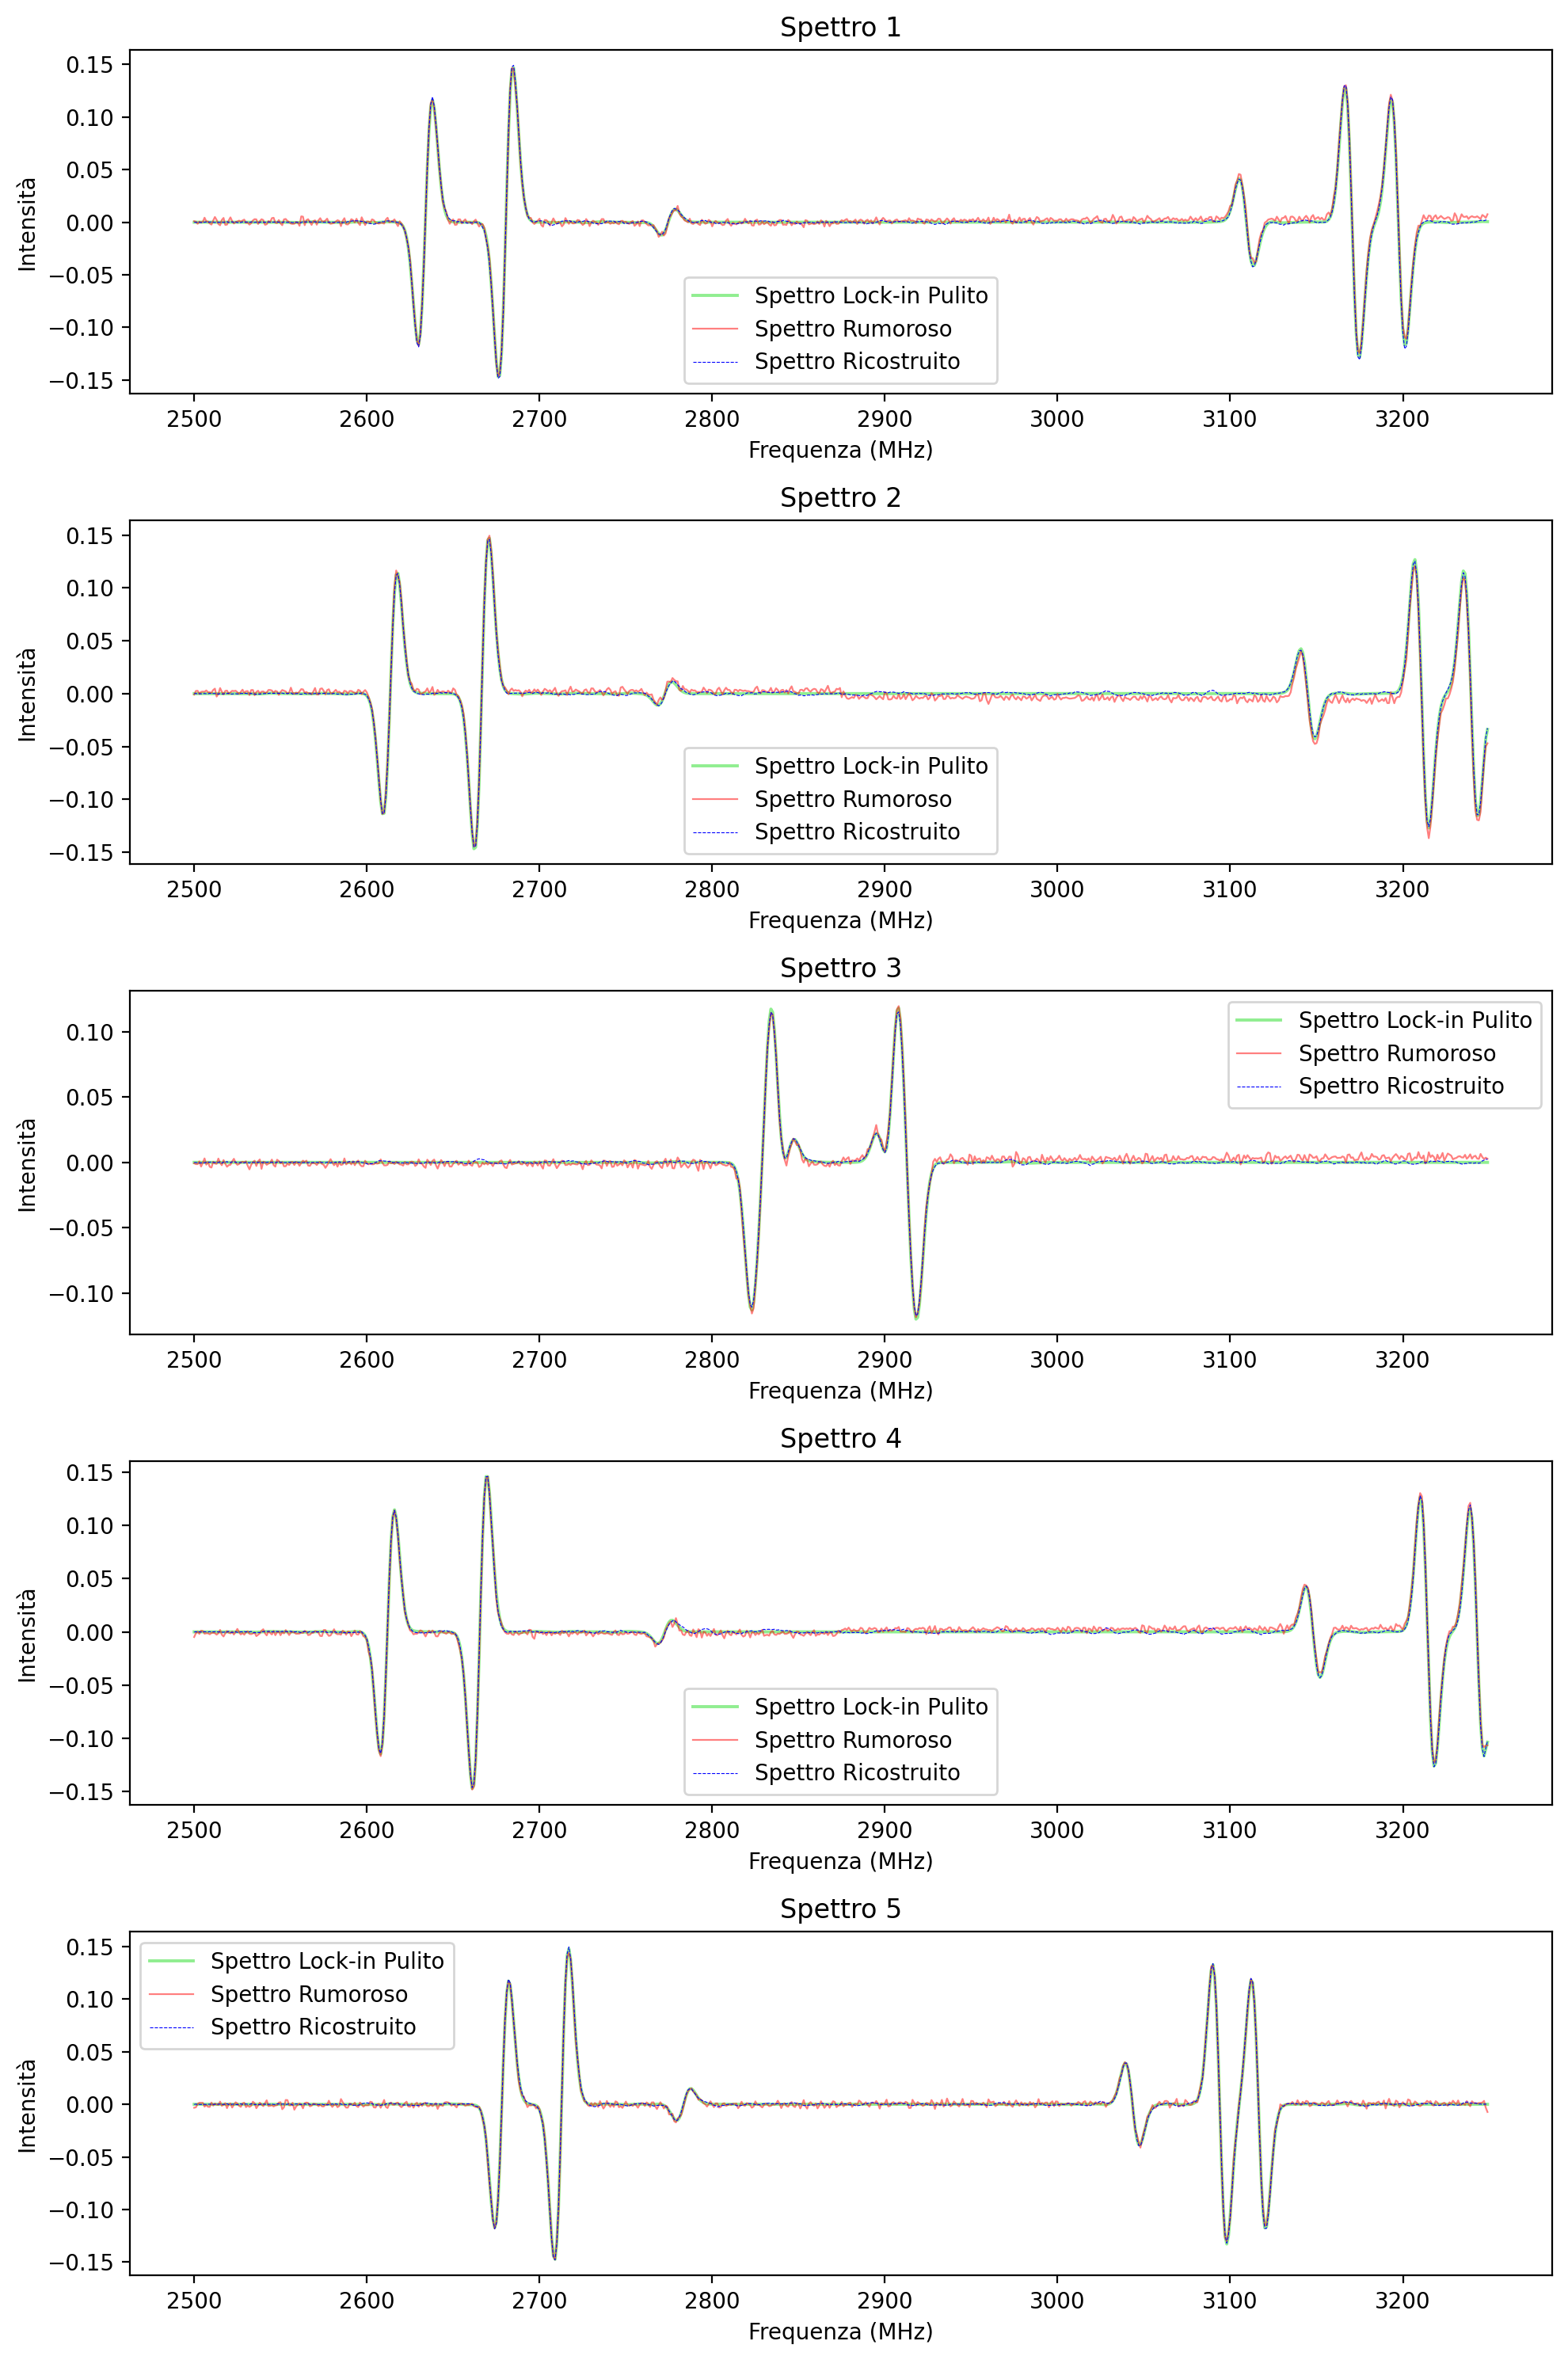

In [14]:
# 5. Ricostruzione (Previsione)
# Simuliamo di voler pulire i primi 5 spettri del nostro dataset
spettri_da_pulire = ds_dx_noisy[:5]
spettri_ricostruiti = model.predict(spettri_da_pulire)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 15), dpi=200)
for i in range(5):
    plt.subplot(5, 1, i+1)
    plt.plot(f, ds_dx[i], label='Spettro Lock-in Pulito', color='lightgreen', linewidth=1.4)
    plt.plot(f, spettri_da_pulire[i], label='Spettro Rumoroso', color='red', alpha=0.5, linewidth=0.8)
    plt.plot(f, spettri_ricostruiti[i], label='Spettro Ricostruito', color='blue', linestyle='dashed', linewidth=0.4)
    plt.legend()
    plt.title(f'Spettro {i+1}')
    plt.xlabel('Frequenza (MHz)')
    plt.ylabel('Intensità')
plt.tight_layout()
plt.show()

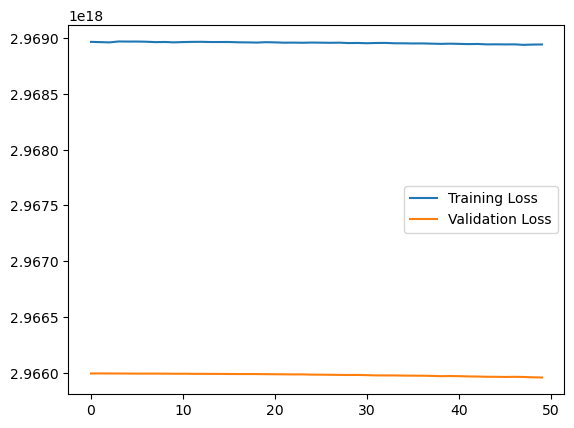

In [ ]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


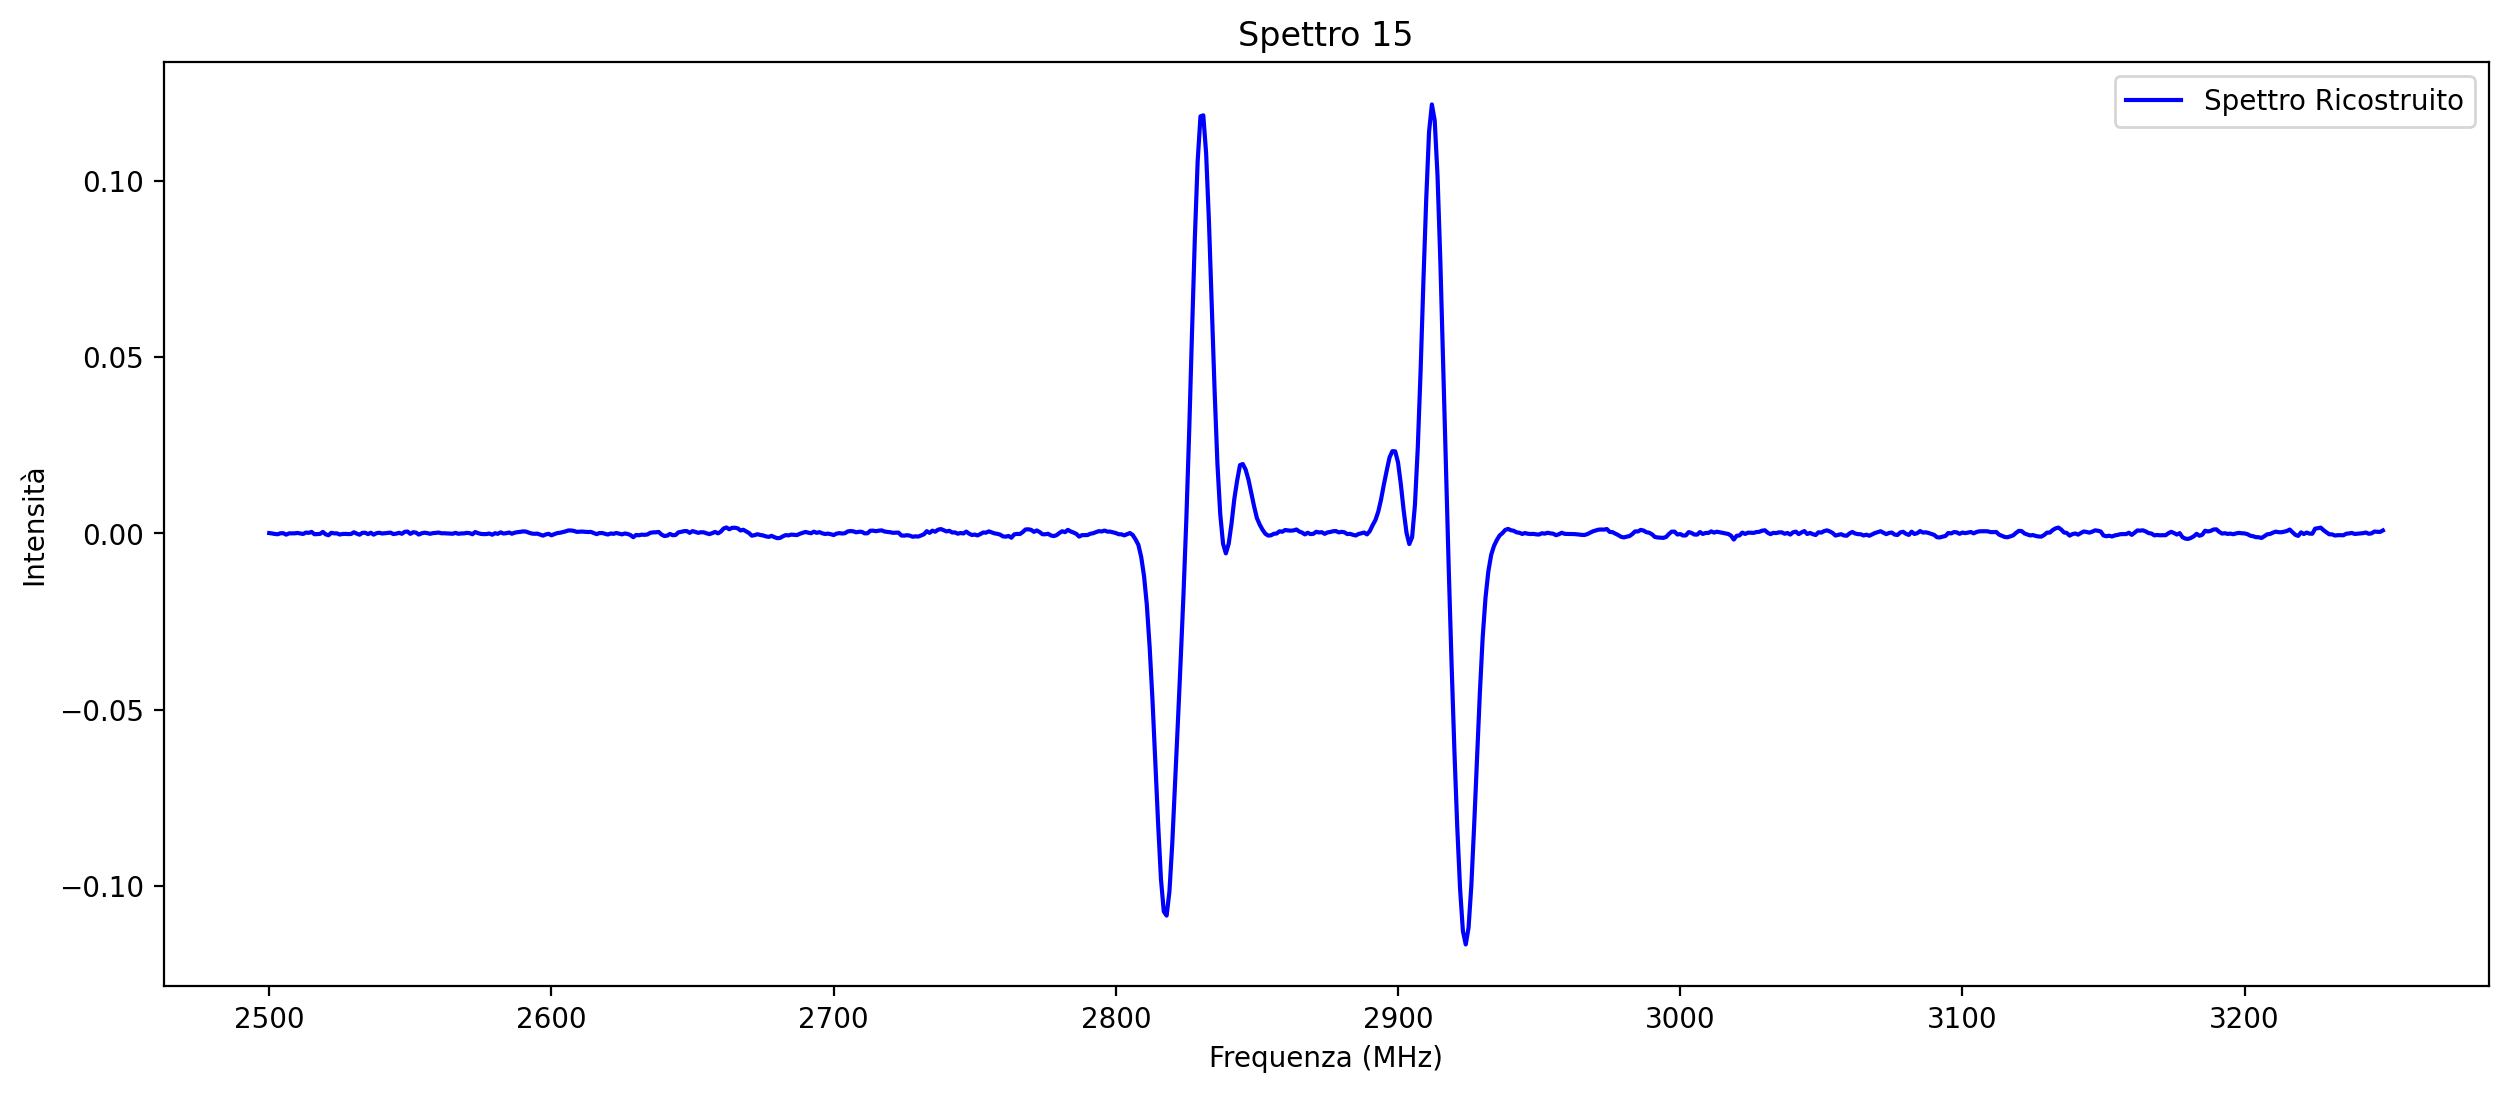

In [26]:
quindicesimo_da_ricostruire = ds_dx_noisy[15:16]  # Prendo solo il 15-esimo spettro (con batch dimension)
quindicesimo_ricostruito = model.predict(quindicesimo_da_ricostruire)

plt.figure(figsize=(15, 6), dpi=200)
#plt.plot(f, ds_dx[15], label='Spettro Lock-in Pulito', color='lightgreen', linewidth=1.4)
#plt.plot(f, ds_dx_noisy[15], label='Spettro Rumoroso', color='red', alpha=0.5, linewidth=0.8)
plt.plot(f, quindicesimo_ricostruito[0], label='Spettro Ricostruito', color='blue') # linestyle='dashed', linewidth=1
plt.legend()
plt.title(f'Spettro {15}')
plt.xlabel('Frequenza (MHz)')
plt.ylabel('Intensità')
#plt.tight_layout()
plt.show()